# Programmatic Optuna Tuning with VAMOS

This notebook shows a full **programmatic** tuning workflow built on VAMOS' algorithm config spaces and the Optuna backend.

We will:
1. start from `build_nsgaii_config_space()`,
2. run an Optuna study across multiple training problems,
3. export the history to JSON and CSV,
4. validate the tuned configuration against a default NSGA-II setup.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vamos import optimize
from vamos.algorithms import NSGAIIConfig
from vamos.engine.tuning import (
    EvalContext,
    Instance,
    ModelBasedTuner,
    TuningTask,
    available_model_based_backends,
    build_nsgaii_config_space,
    config_from_assignment,
    history_to_dict,
    save_history_csv,
    save_history_json,
)
from vamos.foundation.quality_indicators import compute_hypervolume

if not available_model_based_backends().get('optuna'):
    raise RuntimeError("Optuna is not available. Install vamos-optimization[tuning].")


## 1. Build the Search Space and Task

Here we rely on VAMOS' maintained NSGA-II config space instead of hand-coding the parameter definitions.


In [2]:
REF_POINT = np.array([1.1, 1.1])
N_VAR = 20
TRAIN_BUDGET = 1500

config_space = build_nsgaii_config_space()
param_space = config_space.to_param_space()

instances = [
    Instance(name='zdt1', n_var=N_VAR, kwargs={}),
    Instance(name='zdt2', n_var=N_VAR, kwargs={}),
]


def eval_fn(config: dict, ctx: EvalContext) -> float:
    cfg = config_from_assignment('nsgaii', dict(config))
    result = optimize(
        ctx.instance.name,
        algorithm='nsgaii',
        algorithm_config=cfg,
        max_evaluations=ctx.budget,
        seed=ctx.seed,
        n_var=ctx.instance.n_var,
        engine='numba',
    )
    if result.F is None or len(result.F) == 0:
        return 0.0
    return float(compute_hypervolume(result.F, REF_POINT))


task = TuningTask(
    name='programmatic_optuna_nsgaii',
    param_space=param_space,
    instances=instances,
    seeds=[0, 1],
    budget_per_run=TRAIN_BUDGET,
    maximize=True,
    aggregator=np.mean,
)


## 2. Run the Optuna Study

This is the programmatic equivalent of the CLI flow, but it stays inside Python and returns the full trial history directly.


In [3]:
tuner = ModelBasedTuner(
    task=task,
    max_trials=12,
    backend='optuna',
    optuna_sampler='tpe',
    seed=11,
    n_jobs=1,
)

best_config, history = tuner.run(eval_fn, verbose=False)

print(f'Collected {len(history)} trials.')
print('Best configuration keys:', sorted(best_config.keys())[:8], '...')


c:\Users\nicor\Desktop\VAMOS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\nicor\Desktop\VAMOS\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\nicor\Desktop\VAMOS\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-03-08 19:03:54,564] A new study created in memory with name: no-name-28d37716-6ea5-49aa-9325-116d85881acf
[I 2026-03-08 19:03:57,738] Trial 0 finished with value: 0.0 and parameters: {'pop_size': 30, 'offspring_ratio': 0.5, 'selection': 'boltzmann', 'use_external_archive': True, 'initializer': 'random', 'crossover': '

Collected 12 trials.
Best configuration keys: ['archive_prune_policy', 'archive_unbounded', 'blxab_alpha', 'blxab_beta', 'cauchy_gamma', 'crossover', 'crossover_alpha', 'crossover_eta'] ...


## 3. Tabulate and Export the Study

`history_to_dict(...)` gives a notebook-friendly representation, and the save helpers persist the same filtered history that the CLI post-processing uses.


In [4]:
records = history_to_dict(history, task.param_space, include_raw=True)
summary = pd.DataFrame([
    {'trial_id': record['trial_id'], 'score': record['score'], **record['config']}
    for record in records
]).sort_values('score', ascending=False)

artifacts_dir = Path('results/notebooks/21_programmatic_tuning')
save_history_json(history, task.param_space, artifacts_dir / 'history.json', include_raw=True)
save_history_csv(history, task.param_space, artifacts_dir / 'history.csv', include_raw=True)

summary.head(8)


,trial_id,score,pop_size,offspring_ratio,selection,use_external_archive,initializer,crossover,crossover_prob,mutation,...,selection_size,laplace_a,laplace_b,undx_zeta,undx_eta,gaussian_sigma,scatter_base_size_factor,crossover_eta,levy_beta,levy_scale
4,4,0.168710,38,0.5,sus,True,scatter,undx,0.986986,gaussian,...,NaN,NaN,NaN,0.663187,0.948138,0.349090,0.75,NaN,NaN,NaN
6,6,0.060349,126,0.0,ranking,True,random,blx_alpha_beta,0.801758,gaussian,...,NaN,NaN,NaN,NaN,NaN,0.442598,NaN,NaN,NaN,NaN
11,11,0.039630,56,0.5,sus,True,halton,undx,0.912148,gaussian,...,NaN,NaN,NaN,0.519285,0.748692,0.198197,NaN,NaN,NaN,NaN
9,9,0.001791,45,0.5,tournament,False,obl,arithmetic,0.979496,gaussian,...,10.0,NaN,NaN,NaN,NaN,0.410525,NaN,NaN,NaN,NaN
3,3,0.000000,42,0.0,tournament,False,obl,laplace,0.956202,polynomial,...,2.0,0.403098,0.161322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0.000000,22,0.0,sus,False,halton,whole_arithmetic,0.699368,linked_polynomial,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0.000000,109,1.0,random,False,sobol,simplex,0.850090,cauchy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,0,0.000000,30,0.5,boltzmann,True,random,blx_alpha_beta,0.791919,uniform,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


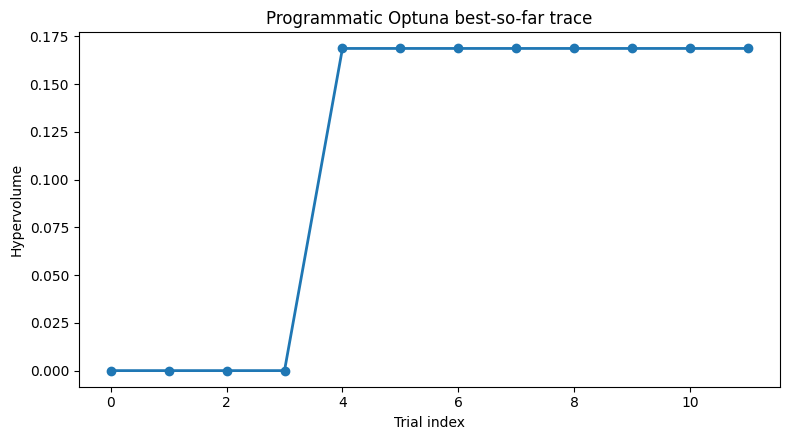

In [5]:
best_so_far = np.maximum.accumulate(summary.sort_values('trial_id')['score'].to_numpy())

plt.figure(figsize=(8, 4.5))
plt.plot(best_so_far, 'o-', linewidth=2)
plt.title('Programmatic Optuna best-so-far trace')
plt.xlabel('Trial index')
plt.ylabel('Hypervolume')
plt.tight_layout()
plt.show()


## 4. Analyze the Real Optuna History

The same study history can be inspected directly in the notebook. This is the fastest way to see whether the search is converging and which parameters seem to matter.


In [6]:
analysis_df = pd.DataFrame([
    {'trial_id': record['trial_id'], 'score': record['score'], **record['config']}
    for record in records
]).sort_values('trial_id').reset_index(drop=True)
analysis_df['best_so_far'] = analysis_df['score'].cummax()
analysis_df.head()


,trial_id,score,pop_size,offspring_ratio,selection,use_external_archive,initializer,crossover,crossover_prob,mutation,...,laplace_a,laplace_b,undx_zeta,undx_eta,gaussian_sigma,scatter_base_size_factor,crossover_eta,levy_beta,levy_scale,best_so_far
0,0,0.00000,30,0.5,boltzmann,True,random,blx_alpha_beta,0.791919,uniform,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000
1,1,0.00000,109,1.0,random,False,sobol,simplex,0.850090,cauchy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000
2,2,0.00000,22,0.0,sus,False,halton,whole_arithmetic,0.699368,linked_polynomial,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000
3,3,0.00000,42,0.0,tournament,False,obl,laplace,0.956202,polynomial,...,0.403098,0.161322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000
4,4,0.16871,38,0.5,sus,True,scatter,undx,0.986986,gaussian,...,NaN,NaN,0.663187,0.948138,0.34909,0.75,NaN,NaN,NaN,0.16871


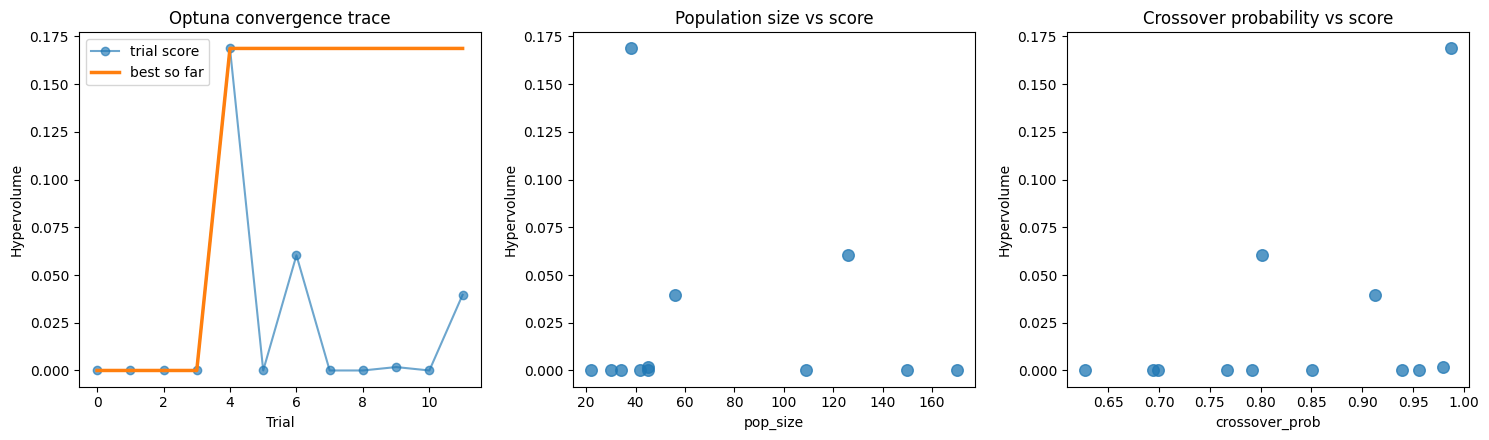

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(analysis_df['trial_id'], analysis_df['score'], 'o-', alpha=0.65, label='trial score')
axes[0].plot(analysis_df['trial_id'], analysis_df['best_so_far'], linewidth=2.5, label='best so far')
axes[0].set_title('Optuna convergence trace')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Hypervolume')
axes[0].legend()

axes[1].scatter(analysis_df['pop_size'], analysis_df['score'], s=70, alpha=0.75)
axes[1].set_title('Population size vs score')
axes[1].set_xlabel('pop_size')
axes[1].set_ylabel('Hypervolume')

axes[2].scatter(analysis_df['crossover_prob'], analysis_df['score'], s=70, alpha=0.75)
axes[2].set_title('Crossover probability vs score')
axes[2].set_xlabel('crossover_prob')
axes[2].set_ylabel('Hypervolume')

plt.tight_layout()
plt.show()


In [8]:
top_slice = analysis_df.sort_values('score', ascending=False).head(5).reset_index(drop=True)
display_cols = ['trial_id', 'score', 'pop_size', 'crossover_prob', 'crossover_eta', 'mutation_eta']
top_slice[display_cols]


,trial_id,score,pop_size,crossover_prob,crossover_eta,mutation_eta
0,4,0.168710,38,0.986986,NaN,25.875141
1,6,0.060349,126,0.801758,NaN,8.615278
2,11,0.039630,56,0.912148,NaN,17.287373
3,9,0.001791,45,0.979496,NaN,22.092175
4,3,0.000000,42,0.956202,NaN,24.686966


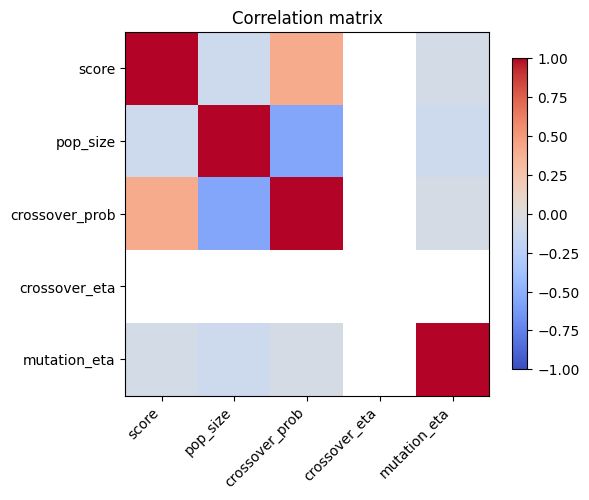

score             1.000000
crossover_prob    0.404497
mutation_eta     -0.067348
pop_size         -0.113236
crossover_eta          NaN
Name: score, dtype: float64

In [9]:
numeric_cols = ['score', 'pop_size', 'crossover_prob', 'crossover_eta', 'mutation_eta']
corr = analysis_df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.to_numpy(), cmap='coolwarm', vmin=-1.0, vmax=1.0)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)), corr.index)
ax.set_title('Correlation matrix')
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

corr['score'].sort_values(ascending=False)


## 5. Validate the Tuned Configuration

Tuning is only half of the workflow. We also want to check whether the tuned configuration beats a standard default on a held-out seed and a larger budget.


In [10]:
VALIDATION_BUDGET = 3000
HOLDOUT_SEEDS = [77, 78]

tuned_cfg = config_from_assignment('nsgaii', dict(best_config))
default_cfg = NSGAIIConfig.default(pop_size=100, n_var=N_VAR)


def evaluate_cfg(cfg) -> float:
    scores = []
    for seed in HOLDOUT_SEEDS:
        result = optimize(
            'zdt1',
            algorithm='nsgaii',
            algorithm_config=cfg,
            max_evaluations=VALIDATION_BUDGET,
            seed=seed,
            n_var=N_VAR,
            engine='numpy',
        )
        scores.append(float(compute_hypervolume(result.F, REF_POINT)))
    return float(np.mean(scores))


tuned_score = evaluate_cfg(tuned_cfg)
default_score = evaluate_cfg(default_cfg)

pd.Series(
    {
        'tuned_mean_hv': tuned_score,
        'default_mean_hv': default_score,
        'delta': tuned_score - default_score,
    }
)


tuned_mean_hv      0.590322
default_mean_hv    0.528970
delta              0.061352
dtype: float64

## Next Steps

- Continue with [33_optuna_tuning_advanced.ipynb](./33_optuna_tuning_advanced.ipynb) for persistent studies, pruning, BOHB-style runs, and multi-fidelity Optuna workflows.
